# Voice Track - Voiceprint Verification

This notebook is the Member 2 (voice) part of the project.

The goal of the voice track is to check a person's voice before they are allowed
into the system. It is the second gate in the pipeline:

```
Face check  >  Voice check  >  Product recommendations
```

In this notebook we:
1. Look at the audio data and explore it (EDA)
2. Show the recordings as waveforms and spectrograms
3. Show what augmentation does to a clip
4. Train the voice check model and measure it (Accuracy, F1, Loss)
5. Run the check on a real member and on a fake stranger

The heavy lifting lives in the scripts in `src/audio/`. This notebook reuses those
same functions so nothing is duplicated, and adds the exploration and explanation.

## Setup

We run everything from the top folder of the project so the file paths work.

In [1]:
import os
from pathlib import Path

# make sure we are at the project root, even if the notebook opens from notebooks/
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('working folder:', Path.cwd())

import sys
sys.path.append('src/audio')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display

working folder: /home/kantoshi/Documents/School/formative_2_data_preprocessing


## 1. Explore the data (EDA)

First we load `audio_features.csv`. This is the file where every recording has been
turned into a row of numbers (made by `src/audio/extract_features.py`).

In [2]:
df = pd.read_csv('data/audio/features/audio_features.csv')
print('rows (clips):', df.shape[0])
print('columns:', df.shape[1])
df.head()

rows (clips): 24
columns: 20


,file,speaker,phrase,source,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,energy,zero_crossing_rate
0,james_approve.wav,james,approve,raw,-461.147369,51.377819,11.088045,17.731800,9.933311,7.277370,-0.638215,-1.869435,-2.189753,-3.035686,-7.326486,-3.423287,-2.672376,3740.885417,0.027691,0.167122
1,james_confirm.wav,james,confirm,raw,-452.872833,57.255676,6.829130,14.264123,5.492644,5.547154,-1.939588,-4.953053,1.134976,-0.126735,-8.984897,-3.616933,-3.037789,3776.041667,0.034053,0.141367
2,kevin_approve.wav,kevin,approve,raw,-321.317017,63.985249,26.279701,21.290047,9.783434,7.974305,5.702089,7.785076,4.114833,-2.927947,-5.581485,0.693030,-6.889484,4343.877033,0.049671,0.162590
3,kevin_confirm.wav,kevin,confirm,raw,-252.727600,92.276840,-1.388516,9.527409,10.604249,6.367171,-0.194778,1.507186,-1.677395,1.278755,1.349632,4.031141,0.140317,2808.019301,0.069824,0.097574
4,sheilla_approve.wav,sheilla,approve,raw,-429.944916,57.308624,8.673522,10.360876,3.587677,5.733167,-1.893806,-1.857316,-3.647233,-4.353362,-3.101889,-3.462800,-6.560427,3907.564975,0.046502,0.151793


In [3]:
# what type is each column, and are there any missing values?
info = pd.DataFrame({
    'type': df.dtypes.astype(str),
    'missing': df.isnull().sum(),
})
info

,type,missing
file,str,0
speaker,str,0
phrase,str,0
source,str,0
mfcc_1,float64,0
mfcc_2,float64,0
mfcc_3,float64,0
mfcc_4,float64,0
mfcc_5,float64,0
mfcc_6,float64,0


In [4]:
# summary statistics for the number columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mfcc_1,24.0,-368.388340,97.738960,-480.615723,-459.240463,-389.099457,-274.836273,-186.436172
mfcc_2,24.0,55.344906,20.610191,18.414789,51.116873,57.696299,64.407433,92.996552
mfcc_3,24.0,9.803153,8.111455,-3.731892,6.336974,8.763298,11.144831,26.856487
mfcc_4,24.0,13.356238,5.379403,2.920933,9.116685,12.678529,17.579808,22.246218
mfcc_5,24.0,6.814985,2.953588,2.175761,4.015249,7.666382,9.621304,11.439830
mfcc_6,24.0,4.057540,3.298323,-4.195162,2.409207,4.957755,6.566047,7.974305
mfcc_7,24.0,-1.046486,3.209214,-6.162045,-3.074129,-1.818379,-0.378980,5.702089
mfcc_8,24.0,-0.597079,4.385594,-5.516689,-3.175842,-1.993351,1.355241,9.693243
mfcc_9,24.0,-1.477857,3.130553,-6.124165,-3.459077,-2.273466,0.344616,5.206904
mfcc_10,24.0,-2.915855,2.957851,-8.173352,-4.247365,-3.063694,-0.859008,2.718713


The labels are `speaker` (who is talking) and `phrase` (what they said). Everything
else is a measured number. There are no missing values.

### Plot 1: how many clips per speaker and phrase

We want to check the data is balanced, so the model is not unfair to anyone.

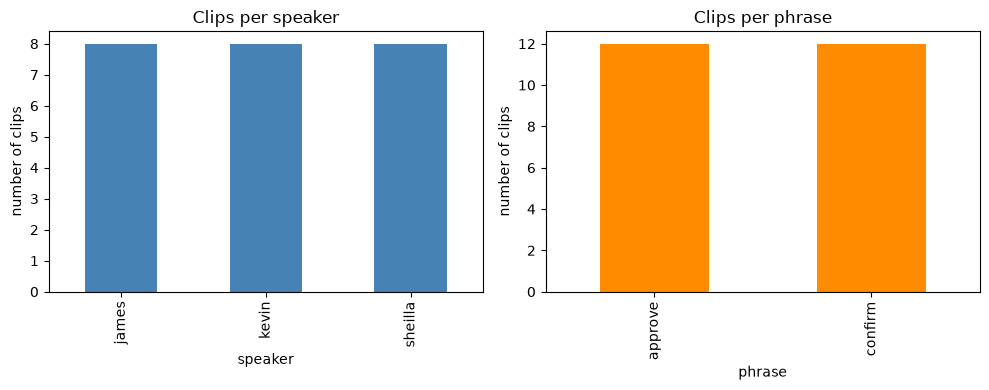

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
df['speaker'].value_counts().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Clips per speaker')
ax1.set_xlabel('speaker'); ax1.set_ylabel('number of clips')

df['phrase'].value_counts().plot(kind='bar', ax=ax2, color='darkorange')
ax2.set_title('Clips per phrase')
ax2.set_xlabel('phrase'); ax2.set_ylabel('number of clips')
plt.tight_layout(); plt.show()

The data is balanced: every speaker has the same number of clips, and both phrases
appear equally. This includes the augmented copies.

### Plot 2: does a feature separate the speakers?

If a number is different for each person, the model can use it to tell them apart.
We look at `mfcc_1`, which describes the overall shape of the voice.

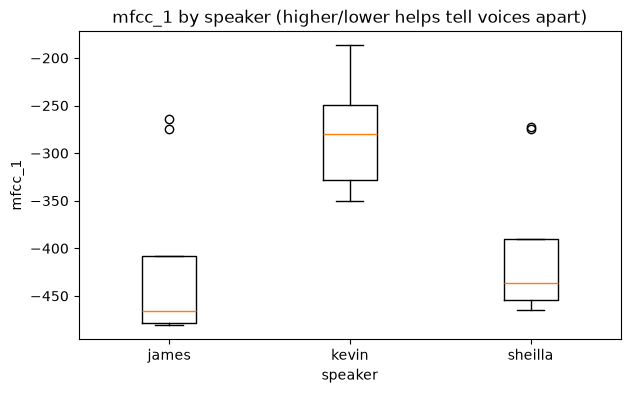

In [6]:
speakers = sorted(df['speaker'].unique())
data = [df[df['speaker'] == s]['mfcc_1'] for s in speakers]

plt.figure(figsize=(7, 4))
plt.boxplot(data, tick_labels=speakers)
plt.title('mfcc_1 by speaker (higher/lower helps tell voices apart)')
plt.xlabel('speaker'); plt.ylabel('mfcc_1')
plt.show()

Kevin's `mfcc_1` sits clearly higher than James's and Sheilla's. That gap is one of
the clues the model uses. James and Sheilla overlap more, which hints they will be
harder to tell apart (we see this again later).

### Plot 3: which features move together (correlation)

If two numbers always rise and fall together, they carry the same information.
A correlation map shows this at a glance.

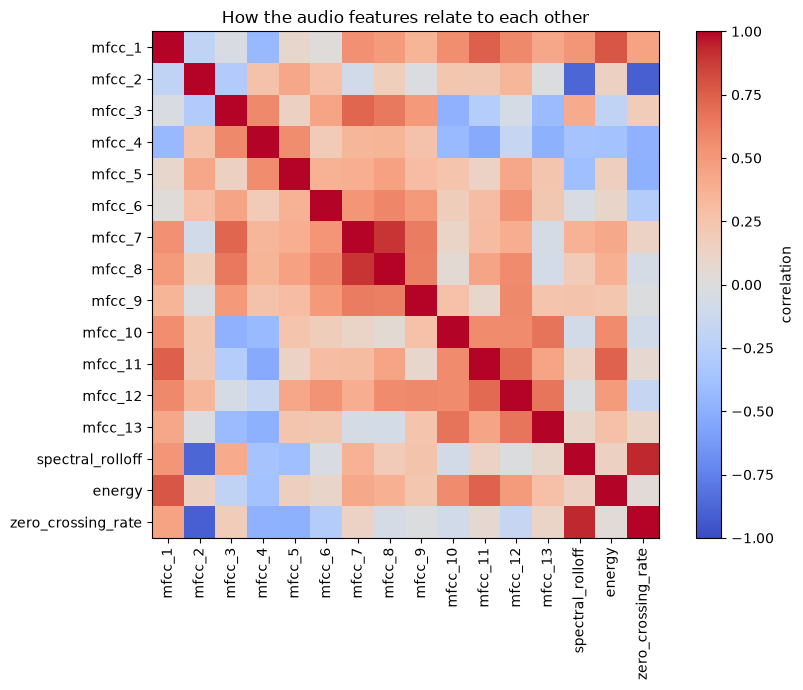

In [7]:
feature_cols = [c for c in df.columns if c not in ['file', 'speaker', 'phrase', 'source']]
corr = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('How the audio features relate to each other')
plt.tight_layout(); plt.show()

Red squares are features that move together, blue squares move opposite. Most of the
MFCC numbers are fairly independent, which is good: each one adds new information.

### Plot 4: a recording as a waveform and a spectrogram

We reuse the `show_clip` function from `src/audio/load_display.py`.

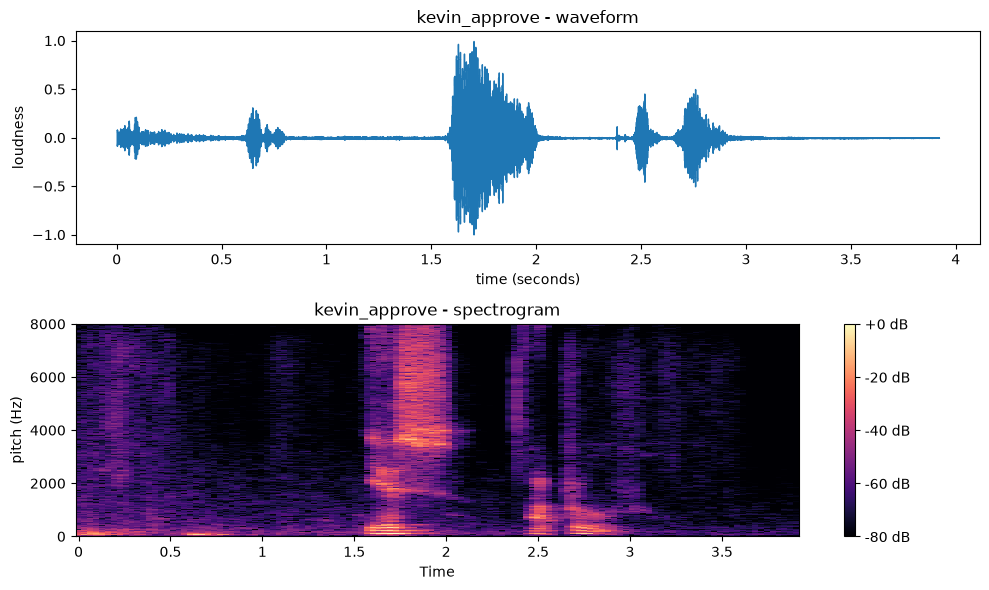

In [8]:
from load_display import show_clip
show_clip(Path('data/audio/raw/kevin_approve.wav'), save=False)
plt.show()

The top picture (waveform) shows the words as bursts of sound with quiet gaps.
The bottom picture (spectrogram) shows the voice energy, mostly in the lower pitches
where speech lives.

## 2. What augmentation does

We make extra copies of each clip by changing the pitch, speeding it up, and adding
noise. This gives the model more to learn from. Here is the original next to the
three copies.

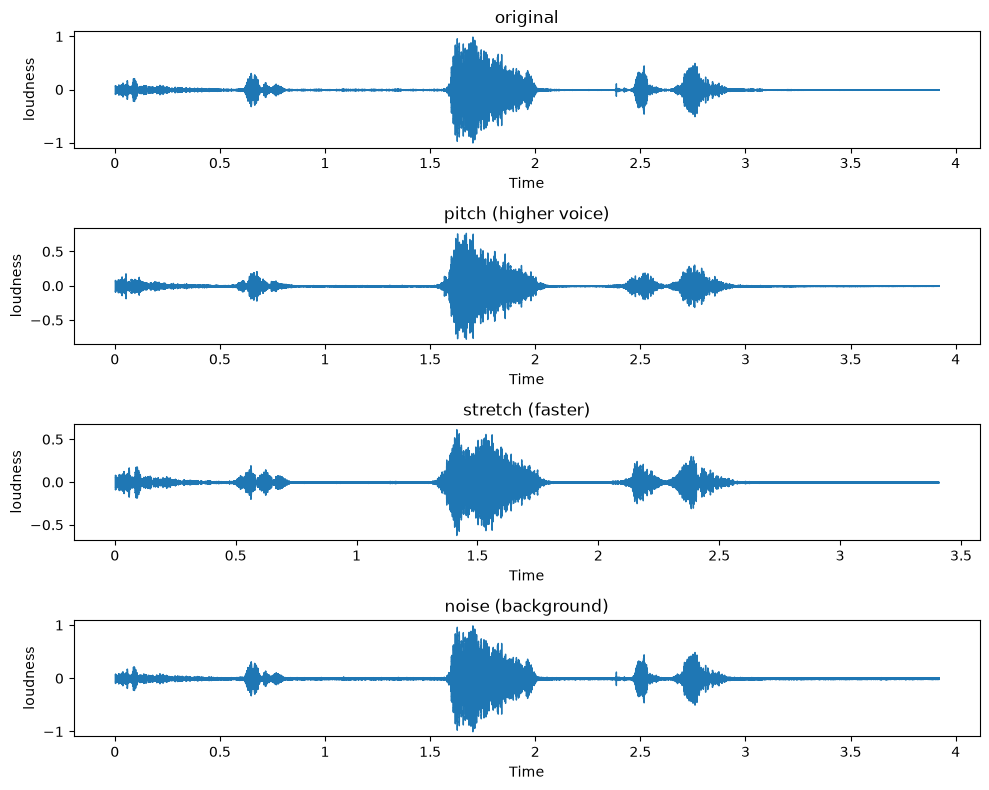

In [9]:
originals = 'data/audio/raw/kevin_approve.wav'
versions = {
    'original': 'data/audio/raw/kevin_approve.wav',
    'pitch (higher voice)': 'data/audio/augmented/kevin_approve_pitch.wav',
    'stretch (faster)': 'data/audio/augmented/kevin_approve_stretch.wav',
    'noise (background)': 'data/audio/augmented/kevin_approve_noise.wav',
}

fig, axes = plt.subplots(len(versions), 1, figsize=(10, 8))
for ax, (label, path) in zip(axes, versions.items()):
    y, sr = librosa.load(path, sr=16000)
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(label); ax.set_ylabel('loudness')
plt.tight_layout(); plt.show()

The stretched copy is shorter (it is faster). The noise copy looks fuzzier. Each copy
is still the same words, so it is a fair extra training example.

## 3. Train the voice check model

We use a Random Forest. It looks at the numbers and learns whose voice a clip is.
We keep some clips aside to test it on, then measure Accuracy, F1, and Loss.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, classification_report

X = df[feature_cols].values
y = df['speaker'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('F1 score:', round(f1_score(y_test, y_pred, average='macro'), 3))
print('Loss    :', round(log_loss(y_test, y_proba, labels=model.classes_), 3))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.833
F1 score: 0.822
Loss    : 0.481

              precision    recall  f1-score   support

       james       1.00      0.50      0.67         2
       kevin       1.00      1.00      1.00         2
     sheilla       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



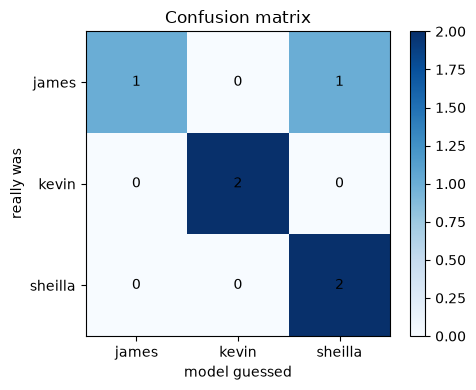

In [11]:
# confusion matrix: rows are the true person, columns are the model's guess
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(model.classes_)), model.classes_)
plt.yticks(range(len(model.classes_)), model.classes_)
plt.xlabel('model guessed'); plt.ylabel('really was')
plt.title('Confusion matrix')
for i in range(len(model.classes_)):
    for j in range(len(model.classes_)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout(); plt.show()

The model gets most clips right. Any mistakes tend to be between James and Sheilla,
the two voices that overlapped in the earlier plot.

## 4. Run the full voice check (real member vs stranger)

This is the part that plugs into the final app. We use the saved model through the
`verify_voice` function from `src/audio/verify.py`.

It passes a clip only if two things are true: the model is sure enough, **and** the
clip actually looks like a real voice. That second check is what blocks strangers.

(If the saved model does not exist yet, run `python src/audio/train_voiceprint.py` first.)

In [12]:
from verify import verify_voice, make_unauthorized_clip, load_model

bundle = load_model()

# a real member should be let in
known = verify_voice('data/audio/raw/kevin_approve.wav', bundle)
print('Real member  ->', 'GRANTED as ' + known['speaker'] if known['granted'] else 'DENIED',
      f"(confidence {known['confidence']:.2f})")

# a fake stranger (buzzer sound) should be blocked
stranger_clip = make_unauthorized_clip()
stranger = verify_voice(stranger_clip, bundle)
print('Fake stranger ->', 'GRANTED as ' + stranger['speaker'] if stranger['granted'] else 'DENIED',
      f"(confidence {stranger['confidence']:.2f})")

Real member  -> GRANTED as kevin (confidence 0.96)
Fake stranger -> DENIED (confidence 0.38)


## Notes and honest limitations

- The system reliably blocks inputs that are **not a human voice** (noise, tones, silence).
- With only a few clips per person, it cannot yet reliably block an **unknown human**
  voice. Two members' voices overlapped in the data, so a stranger who happened to
  sound similar could slip through.
- The fix is simple and does not need any code changes: each member records more takes
  of each phrase, and we can add richer voice features. Re-running the scripts will
  then produce a stronger model.

## Summary

- Explored the audio features, checked balance, and plotted the data four ways.
- Showed waveforms, spectrograms, and what augmentation does.
- Trained a Random Forest voice check and measured it with Accuracy, F1, and Loss.
- Ran the full check: a real member is let in, a fake stranger is blocked.

This voice check is the second gate in the pipeline. The final app (Member 3) calls
`verify_voice` after the face check passes.